# CPU+GPU Test of `calcSpatialFreqsFilterBank`

This notebook replicates in Python/NumPy the MATLAB test script `testCalcSpatialFreqsFilterBank.m` for the FilterBank local spatial-frequency estimator `calcSpatialFreqsFilterBank`. The core functions are imported from `FPA_Numpy.py` and `FPA_TensorFlow.py` .
Here we check NumPy-CPU and TensorFlow-GPU implementations

In [ ]:
# ---
# ✅ Colab bootstrap for LensPMD
# How to open in Colab:
# 1) Clone the LensPMD repo into Google Drive.
# 2) In Drive (web), right-click the notebook → “Open with” → “Google Colab”.
# 3) Run this cell to mount Drive, set the working directory, and verify required paths.
# ---

import os
from pathlib import Path

# === Detect Colab =============================================================
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"Running in Colab? {IN_COLAB}")

# === Setup when in Colab ======================================================
if IN_COLAB:
    from google.colab import drive  # type: ignore
    DRIVE_MOUNT_POINT = "/content/drive"
    PROJECT_REL_PATH = "MyDrive/Colab Notebooks/72_OM4M008_LENSPMD25_CPU_GPU_FPA/Python_src"
    REQUIRED_PATH = "/content/drive/MyDrive/Colab Notebooks/72_OM4M008_LENSPMD25_CPU_GPU_FPA/local_data"

    # Mount Google Drive
    drive.mount(DRIVE_MOUNT_POINT, force_remount=True)

    # Set working directory
    project_path = Path(DRIVE_MOUNT_POINT) / PROJECT_REL_PATH
    if not project_path.exists():
        raise FileNotFoundError(f"❌ Project directory not found: {project_path}")

    os.chdir(project_path)
    print("✅ Working Directory:", Path.cwd())

    # Verify required local_data folder exists
    local_data_path = Path(REQUIRED_PATH)
    if not local_data_path.exists():
        raise FileNotFoundError(
            f"❌ Required directory not found: {local_data_path}\n"
            "Please ensure 'local_data' exists in the LensPMD folder in your Drive."
        )

    print("✅ Required folder found:", local_data_path)
    print("📂 Files in Working Directory:", os.listdir())

else:
    print("Not running in Colab — skipping Drive mount and WD setup.")
    print("Current Working Directory:", Path.cwd())


In [ ]:
# para forzar que los imshow en modo debug vayan al notebook desde el que se hace la llamada 



import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

import matplotlib
%matplotlib inline



from FPA_Numpy import calcSpatialFreqsHilbert2D_NumPy, calcSpatialFreqsFilterbank_ParVer_NumPy
from FPA_TensorFlow import calcSpatialFreqsHilbert2D_TF, calcSpatialFreqsFilterbank_ParVer_TF
from FPA_Utils import time_function, peaks_2d

from functools import partial

# check for tensor flow and list devices
print("TensorFlow version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPU devices:", tf.config.list_physical_devices('GPU'))
if tf.config.list_physical_devices('GPU'):
    try:
        for d in tf.config.list_physical_devices('GPU'):
            tf.config.experimental.set_memory_growth(d, True)
    except Exception as e:
        print("Could not set memory growth:", e)

print("CPU devices:", tf.config.list_physical_devices('CPU'))



In [ ]:
# Synthetic interferogram (Caso 1: HIFREQ)
NR, NC = 558, 553
y, x = np.meshgrid(
    np.arange(NR, dtype=np.float32),
    np.arange(NC, dtype=np.float32),
    indexing="ij",
)
x = x - 0.5 * NC
y = y - 0.5 * NR

# ROI mask
M = np.ones((NR, NC), dtype=bool)

# Spatial carrier
w0 = np.array([np.pi/4, np.pi/4], dtype=np.float32)  # rad/px
fringe_carrier_or = np.arctan2(w0[1], w0[0])

# Smooth phase term via peaks (already sized NR x NC)
phi_0 = 3.0 * peaks_2d(NR, NC)
phi = phi_0 + w0[0] * x + w0[1] * y

# Ground-truth spatial freqs
phi_y, phi_x = np.gradient(phi.astype(np.float32))  # np.gradient -> (d/dy, d/dx)
w_phi = np.abs(phi_x + 1j * phi_y)
w_phi = w_phi * M  # apply mask
theta_or = np.arctan2(-phi_y, phi_x)

# DC and modulation in gray values
b = np.float32(100.0)
m = np.float32(64.0)
nL_mod = np.float32(0.0)
nL = 100.0 * nL_mod / m  # not used explicitly

# Interferogram in [0, 255]
g_float = b + m * np.cos(phi) + nL_mod * np.random.randn(NR, NC).astype(np.float32)
g_uint8 = np.clip(np.round(g_float), 0, 255).astype(np.uint8)
g = g_uint8.astype(np.float32)
g = g * M.astype(np.float32)

# Ground-truth phasor (for reference)
z = b * np.exp(1j * phi)
print("Synthetic interferogram generated.")


In [ ]:
# Time numpy paralell filter bank method (outputs kept if needed)
# use partial to keep funcion metadata
f_calcSpatialFreqsFilterbank_ParVer_NumPy = partial(calcSpatialFreqsFilterbank_ParVer_NumPy, g, M)

# Time  numpy paralell filter bank method and keep outputs for plotting
res_calcSpatialFreqsFilterbank_ParVer_NumPy = time_function(f_calcSpatialFreqsFilterbank_ParVer_NumPy.func.__name__, f_calcSpatialFreqsFilterbank_ParVer_NumPy, n_runs=1, verbose=True)

# calculate spatial freqs
(pred_w_phi, pred_theta_or, pred_phi_x, pred_phi_y, M_proc)=f_calcSpatialFreqsFilterbank_ParVer_NumPy()

# Error map (only meaningful where M is True)
error_map_w_phi = pred_w_phi - w_phi
mask = M

# Display w_phi estimate
plt.figure(figsize=(6, 5))
plt.imshow(pred_w_phi * M_proc, origin='upper')
plt.colorbar(label=r'$w_\phi$ (rad/px)')
plt.title(r'Estimated $w_\phi$ (rad/px)')
plt.tight_layout()
plt.show()

# Histogram of error in w_phi (rad/px)
histEdge2 = np.linspace(-np.pi/10, np.pi/10, 100)
plt.figure(figsize=(6, 4))
plt.hist(error_map_w_phi[mask].ravel(), bins=histEdge2)
plt.title('Histogram of error in $w_\phi$')
plt.xlabel(r'$w_\phi$ error (rad/px)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# RMSE criterion
rmse_w_phi = np.sqrt(np.mean(error_map_w_phi[mask] ** 2))
print(f"RMSE(w_phi) = {rmse_w_phi:.4f} rad/px")
assert rmse_w_phi < 0.4, "RMSE condition failed (rmse_w_phi >= 0.4 rad/px)"
print("Assertion passed: RMSE(w_phi) < 0.4 rad/px")


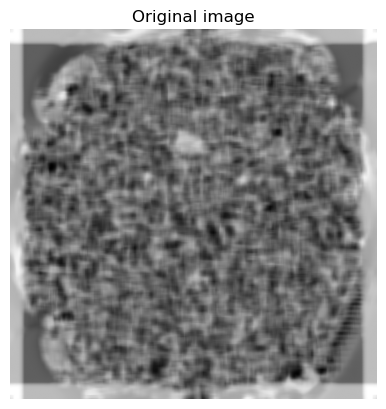

[calcSpatialFreqsFilterbank_ParVer_TF] Warm-up time: 105901.68 ms
[calcSpatialFreqsFilterbank_ParVer_TF] Run 1/1: 530.33 ms
calcSpatialFreqsFilterbank_ParVer_TF: 1 runs -> mean = 530.33 ms, std = 0.00 ms


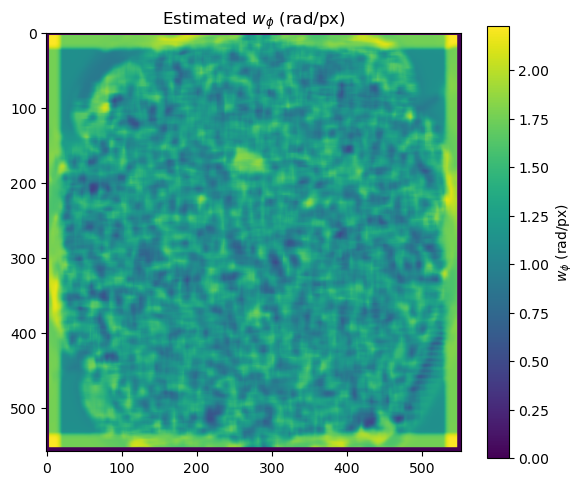

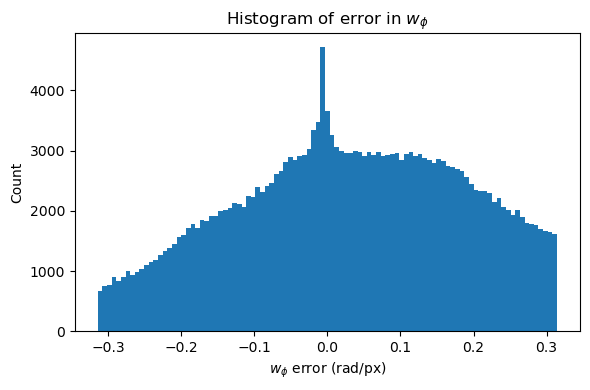

RMSE(w_phi) = 0.3257 rad/px
Assertion passed: RMSE(w_phi) < 0.4 rad/px


In [9]:
#this is to avoid restrting the kernel while iterating
import importlib
import FPA_TensorFlow

importlib.reload(FPA_TensorFlow)
from FPA_TensorFlow import calcSpatialFreqsFilterbank_ParVer_TF


# Time tensor flow paralell filter bank method (outputs kept if needed)
# use partial to keep funcion metadata
f_calcSpatialFreqsFilterbank_ParVer_TF = partial(calcSpatialFreqsFilterbank_ParVer_TF, g, M)

# Time tensor flow paralell filter bank method and keep outputs for plotting
res_calcSpatialFreqsFilterbank_ParVer_TF = time_function(f_calcSpatialFreqsFilterbank_ParVer_TF.func.__name__, f_calcSpatialFreqsFilterbank_ParVer_TF, n_runs=1, verbose=True)

# calculate spatial freqs
(pred_w_phi, pred_theta_or, pred_phi_x, pred_phi_y, M_proc)=f_calcSpatialFreqsFilterbank_ParVer_TF()


# Error map (only meaningful where M is True)
error_map_w_phi = pred_w_phi - w_phi
mask = M

# Display w_phi estimate
plt.figure(figsize=(6, 5))
plt.imshow(pred_w_phi * M_proc, origin='upper')
plt.colorbar(label=r'$w_\phi$ (rad/px)')
plt.title(r'Estimated $w_\phi$ (rad/px)')
plt.tight_layout()
plt.show()

# Histogram of error in w_phi (rad/px)
histEdge2 = np.linspace(-np.pi/10, np.pi/10, 100)
plt.figure(figsize=(6, 4))
plt.hist(error_map_w_phi[mask].ravel(), bins=histEdge2)
plt.title('Histogram of error in $w_\phi$')
plt.xlabel(r'$w_\phi$ error (rad/px)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# RMSE criterion
rmse_w_phi = np.sqrt(np.mean(error_map_w_phi[mask] ** 2))
print(f"RMSE(w_phi) = {rmse_w_phi:.4f} rad/px")
assert rmse_w_phi < 0.4, "RMSE condition failed (rmse_w_phi >= 0.4 rad/px)"
print("Assertion passed: RMSE(w_phi) < 0.4 rad/px")


In [ ]:
%%prun -D out.prof
# profile the function call, the cell magic must be the first line of the cell

(pred_w_phi, pred_theta_or, pred_phi_x, pred_phi_y, M_proc)=calcSpatialFreqsFilterbank_ParVer_TF(g, M)


In [ ]:
# analyze profiler report
CODE_PROFILE_ANALYIS=False
if CODE_PROFILE_ANALYIS:
    import snakeviz
    print(snakeviz.__file__)
    !snakeviz out.prof

Generacion de informe
correr la celda de abajo para generar un informe HTML

In [ ]:
# --- AUTOMATED EXPORT CELL: Generate HTML (no code) for PDF printing ---
# check nbconvert is installed "pip show nbconvert"
import os
from IPython.display import FileLink, Javascript

nb_name = "testCalcSpatialFreqsFilterBank_CPU-GPU.ipynb"
html_name = nb_name.replace(".ipynb", "_REPORT.html")

print("Saving notebook…")
import ipywidgets as widgets
from IPython.display import Javascript

# Save the notebook
display(Javascript("Jupyter.notebook.save_checkpoint();"))

# Export to HTML (no input code)
cmd = f"jupyter nbconvert --to html --no-input --no-prompt {nb_name} --output {html_name}"
print("Running:", cmd)
os.system(cmd)

print("\nHTML report generated:", html_name)
display(FileLink(html_name))

print("\n➡️ Now open the HTML and choose **Print → Save as PDF**.")
